# Linearized Laplace (GLM Predictive)

Exact Gaussian predictive without sampling via network linearization.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

from deepuq.models import MLP
from deepuq.methods import LaplaceWrapper

## Generate Data

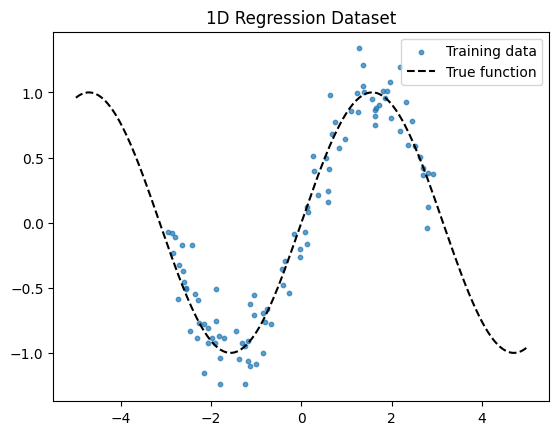

In [2]:
np.random.seed(42)
torch.manual_seed(42)

# 1D regression data
n_train = 100
x_train = np.random.uniform(-3, 3, (n_train, 1)).astype(np.float32)
y_train = np.sin(x_train) + 0.2 * np.random.randn(n_train, 1).astype(np.float32)

x_test = np.linspace(-5, 5, 200).reshape(-1, 1).astype(np.float32)

X_train = torch.from_numpy(x_train)
Y_train = torch.from_numpy(y_train)
X_test = torch.from_numpy(x_test)

plt.scatter(x_train, y_train, s=10, alpha=0.7, label="Training data")
plt.plot(x_test, np.sin(x_test), "k--", label="True function")
plt.legend()
plt.title("1D Regression Dataset")
plt.show()

## Train Model & Fit Laplace

In [3]:
# Train MLP
model = MLP(input_dim=1, hidden_dims=[64, 64], output_dim=1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(1000):
    pred = model(X_train)
    loss = torch.nn.functional.mse_loss(pred, Y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"Final training loss: {loss.item():.4f}")

# Fit Laplace approximation
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=len(X_train))

la = LaplaceWrapper(model, likelihood="regression", hessian_structure="diag")
la.fit(train_loader)
la.optimize_prior_precision()
print("Laplace approximation fitted.")

Final training loss: 0.0278
Laplace approximation fitted.


## Compare Sampling vs GLM Predictive

In [4]:
# Sampling-based predictive
start = time.time()
result_samp = la.predict_uq(X_test, method="sampling")
mean_samp = result_samp.mean
std_samp = result_samp.total_var.sqrt()
time_sampling = time.time() - start

# GLM predictive (linearized)
start = time.time()
result_glm = la.predict_uq(X_test, method="glm")
mean_glm = result_glm.mean
std_glm = result_glm.epistemic_var.sqrt()
time_glm = time.time() - start

print(f"Sampling time: {time_sampling:.3f}s")
print(f"GLM time:      {time_glm:.3f}s")
print(f"Speedup:       {time_sampling / max(time_glm, 0.001):.1f}x")

Sampling time: 0.014s
GLM time:      0.012s
Speedup:       1.2x


## Visualize

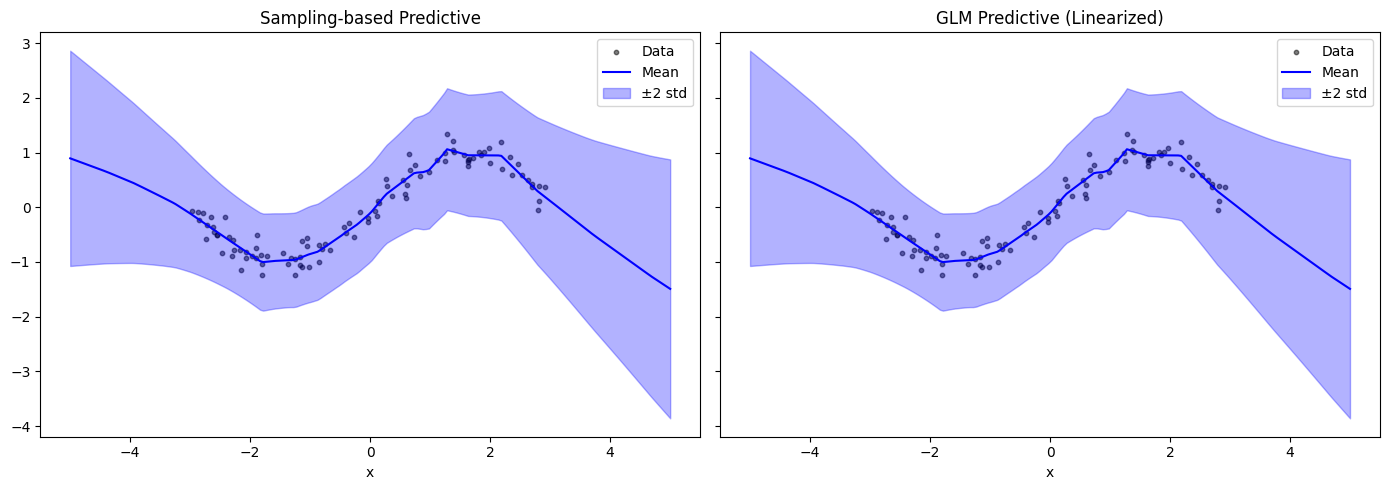

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

x_np = x_test.flatten()

for ax, mean, std, title in zip(
    axes,
    [mean_samp, mean_glm],
    [std_samp, std_glm],
    ["Sampling-based Predictive", "GLM Predictive (Linearized)"],
):
    mean_np = mean.detach().numpy().flatten()
    std_np = std.detach().numpy().flatten()

    ax.scatter(x_train, y_train, s=10, alpha=0.5, color="black", label="Data")
    ax.plot(x_np, mean_np, "b-", label="Mean")
    ax.fill_between(
        x_np,
        mean_np - 2 * std_np,
        mean_np + 2 * std_np,
        alpha=0.3,
        color="blue",
        label="±2 std",
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.legend()

plt.tight_layout()
plt.show()

## OOD Behavior

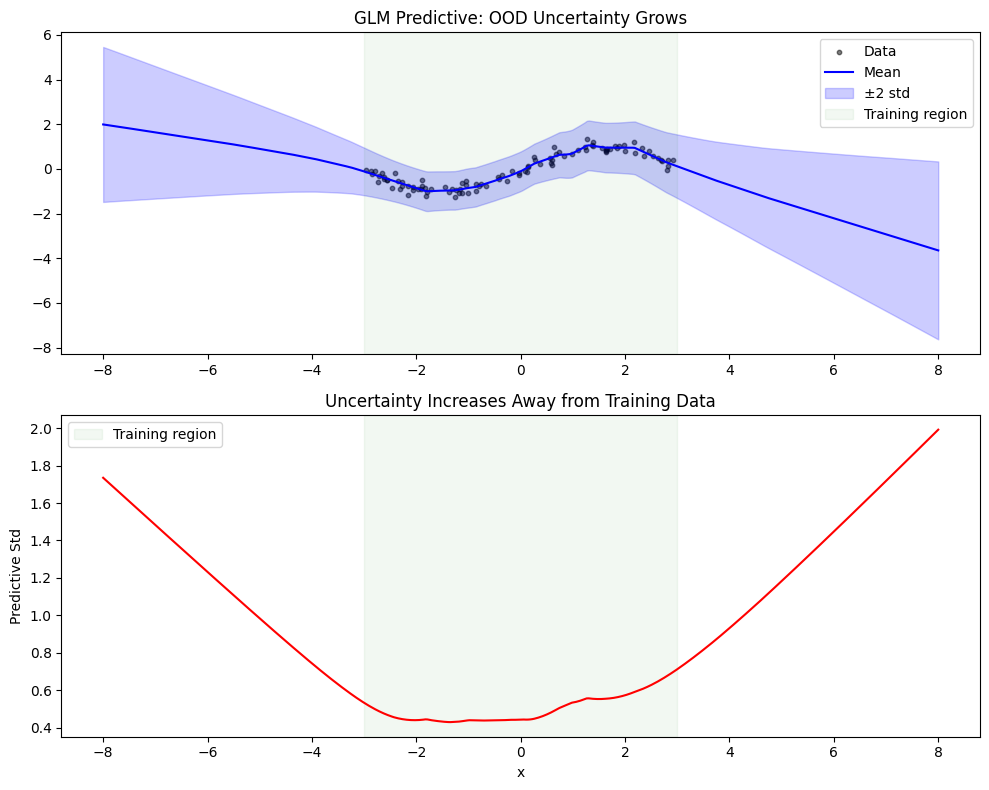

In [6]:
# Evaluate uncertainty at different distances from training data
x_ood = np.linspace(-8, 8, 400).reshape(-1, 1).astype(np.float32)
X_ood = torch.from_numpy(x_ood)

result_ood = la.predict_uq(X_ood, method="glm")
mean_ood = result_ood.mean
std_ood = result_ood.epistemic_var.sqrt()
mean_ood_np = mean_ood.detach().numpy().flatten()
std_ood_np = std_ood.detach().numpy().flatten()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Top: predictions with uncertainty
axes[0].scatter(x_train, y_train, s=10, alpha=0.5, color="black", label="Data")
axes[0].plot(x_ood.flatten(), mean_ood_np, "b-", label="Mean")
axes[0].fill_between(
    x_ood.flatten(),
    mean_ood_np - 2 * std_ood_np,
    mean_ood_np + 2 * std_ood_np,
    alpha=0.2, color="blue", label="\u00b12 std",
)
axes[0].axvspan(-3, 3, alpha=0.05, color="green", label="Training region")
axes[0].set_title("GLM Predictive: OOD Uncertainty Grows")
axes[0].legend()

# Bottom: uncertainty as function of x
axes[1].plot(x_ood.flatten(), std_ood_np, "r-")
axes[1].axvspan(-3, 3, alpha=0.05, color="green", label="Training region")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Predictive Std")
axes[1].set_title("Uncertainty Increases Away from Training Data")
axes[1].legend()

plt.tight_layout()
plt.show()